In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [9]:
#Loading data from CSV 
df=pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
#A) Use .info(),.describe(),.value_count()
#Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
#Summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
#Value count for categorical columns
print(df['Survived'].value_counts())
print(df['Pclass'].value_counts())
print(df['Sex'].value_counts())
print(df['Embarked'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


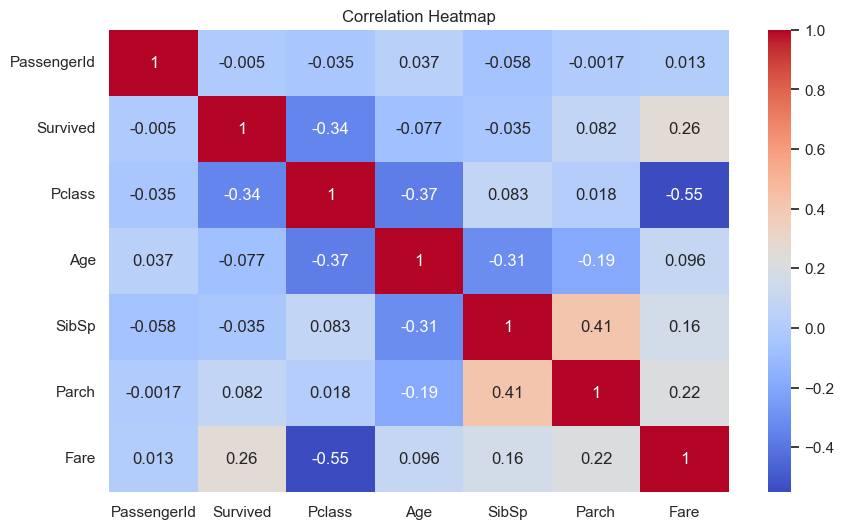

In [19]:
#B) Use ns.pairplot(),.sns.heatmap() for visualization

# Correlation Heatmap
# Keep only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Plot the correlation heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Observation:

#Fare has a positive correlation (~0.26) with Survived, meaning passengers who paid higher fares were more likely to survive.

#Pclass has a negative correlation (~-0.34) with Survived, indicating that 1st class passengers had a better chance of survival.

#Sex also shows a strong correlation with survival, since most survivors were female.

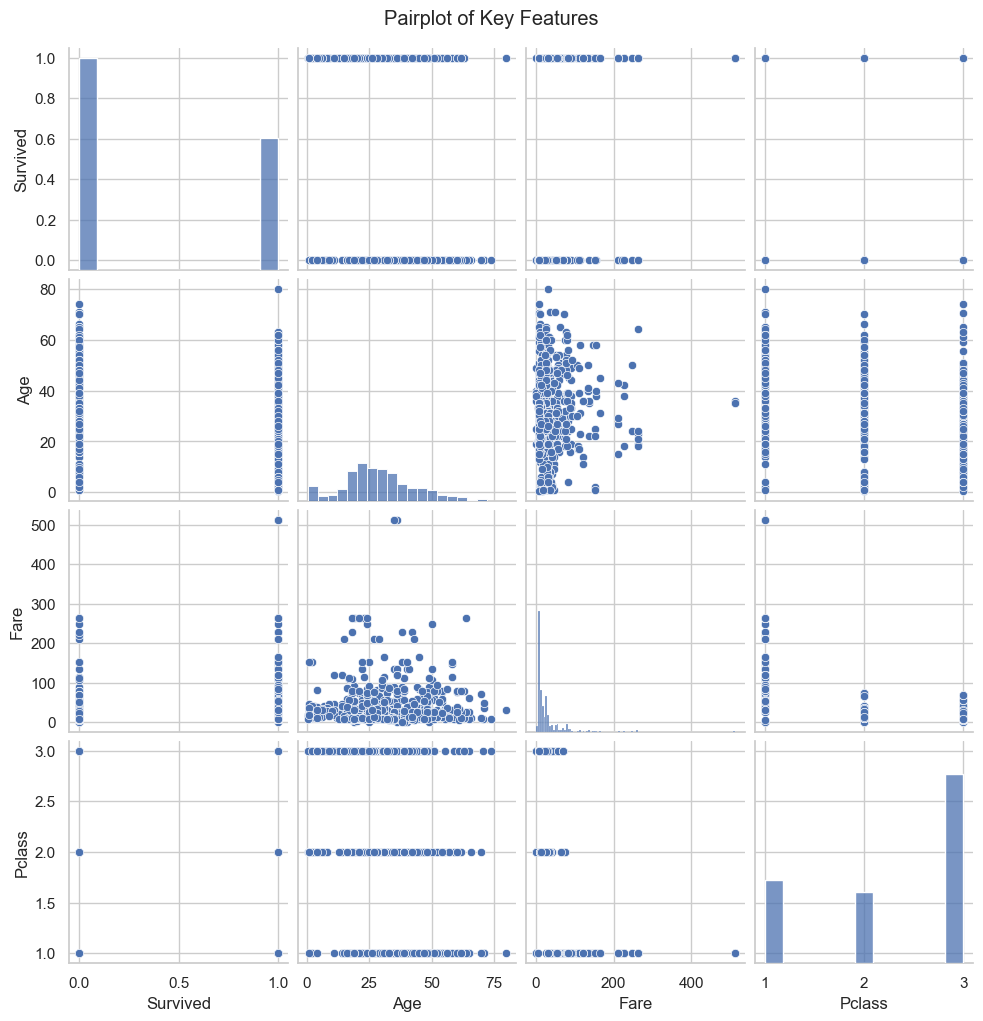

In [20]:
# Pairplot

sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass', 'Sex']])
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

#Observation:

#Clusters of survivors are visible around lower Pclass values and higher Fare.

#Many female passengers are in the survival group.

#Younger age groups show slightly better survival patterns.

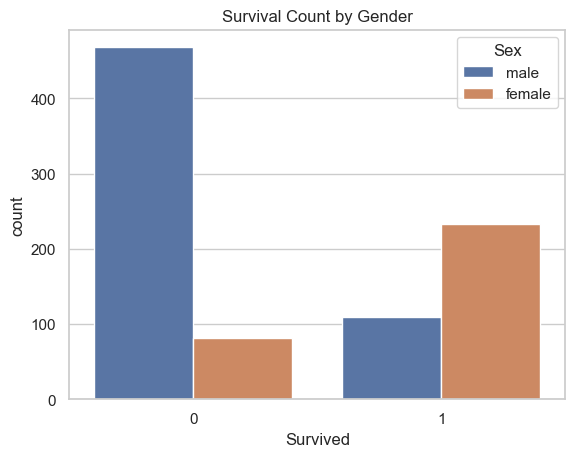

In [24]:
#C) identifying Realtionship and trends

#1.)Survival by gender

sns.countplot(x='Survived',hue='Sex',data=df)
plt.title("Survival Count by Gender")
plt.show()

#Observation:

#A significantly higher number of females survived compared to males.

#This supports the evacuation policy of “women and children first.”


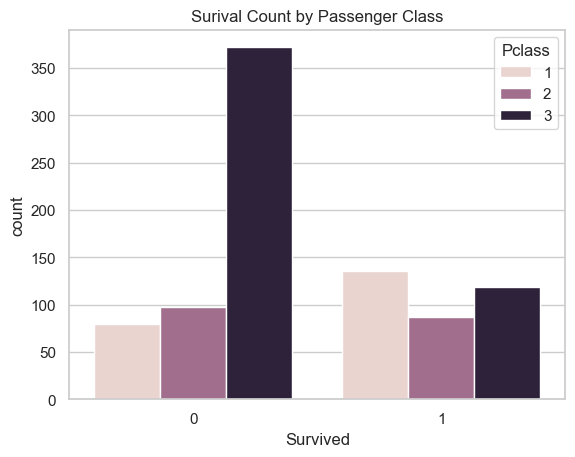

In [25]:
#2.) Surival by passenger class

sns.countplot(x='Survived',hue='Pclass',data=df)
plt.title("Surival Count by Passenger Class")
plt.show()

#Observation:

#1st class passengers had the highest survival rate.

#3rd class passengers had the lowest chance of survival.

#Class clearly influenced survival.



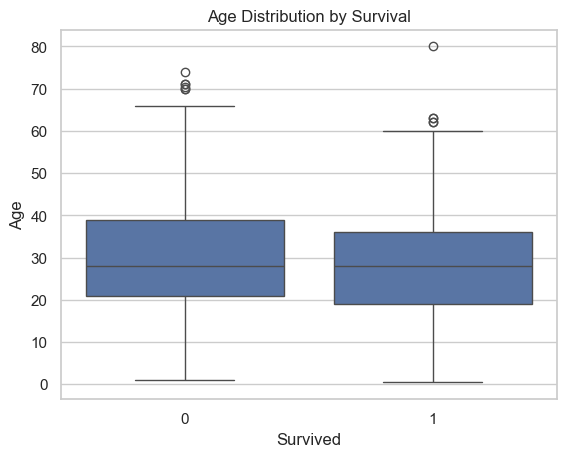

In [27]:
#3.) Age vs Survival

sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution by Survival")
plt.show()

#Observation:

#Survivors tended to be younger on average than non-survivors.

#Several outliers in both groups indicate a wide spread in ages.



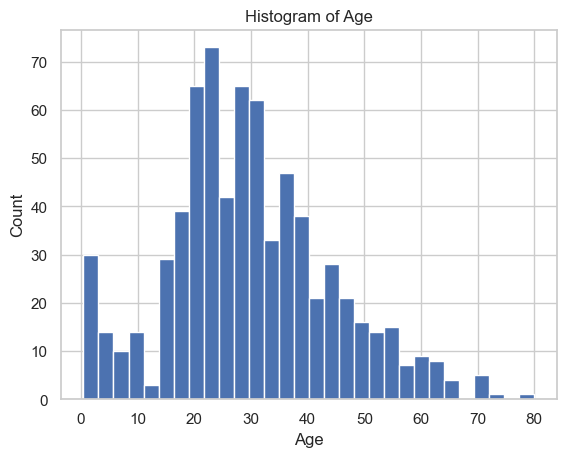

In [29]:
#D) Plot histogram,boxplots,scatterplot

# Histogram of Age
df['Age'].hist(bins=30)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#Observation:

#Most passengers were between 20 to 40 years old.

#Few older passengers; a small number of children on board.



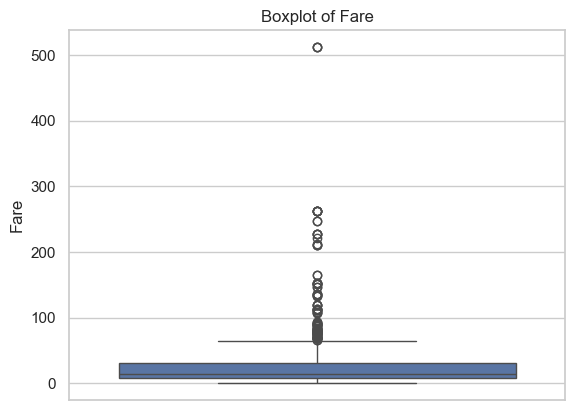

In [30]:
# Boxplot of Fare

sns.boxplot(y='Fare', data=df)
plt.title("Boxplot of Fare")
plt.show()

#Observation:

#Majority of passengers paid less than 100 units.

#A few outliers paid very high fares, likely indicating VIP or 1st class.



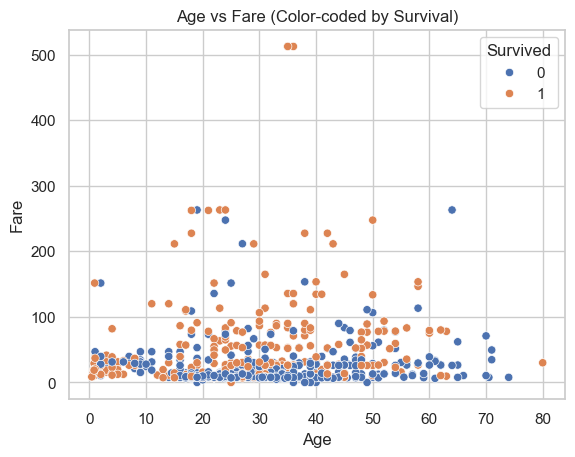

In [31]:
# Scatterplot:Age vs Fare

sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare (Color-coded by Survival)")
plt.show()

#Observation:

#Higher Fare + Lower Age = better chance of survival.

#Some elderly passengers also paid high fares and survived, suggesting class mattered.

